In [2]:
!pip install pandas matplotlib seaborn ipykernel --quiet

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything imported successfully")

Everything imported successfully


In [4]:
!pip install seaborn

In [5]:
import seaborn as sns

print("Seaborn installed!")

Seaborn installed!


In [7]:
import sys
print(sys.executable)

C:\Users\eyobg\Desktop\Internship Training\notebook\week1\Scripts\python.exe


In [8]:
import os
print(os.getcwd())

C:\Users\eyobg\Desktop\Internship Training\notebook\week1-slack-analysis\notebooks


In [9]:
import sys
!"{sys.executable}" -m pip install seaborn

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything works!")

Everything works!


In [11]:
import json
import os
import pprint

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime

# Plot style
plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

# Path to the dataset
DATA_PATH = '../data'

print('Data path exists:', os.path.exists(DATA_PATH))
print('Available channels:', os.listdir(DATA_PATH)[:5], '...')

Data path exists: True
Available channels: ['ab_test-group', 'adludios-challange', 'all-broadcast', 'all-career-exercises', 'all-community-building'] ...


In [12]:
def load_channel(data_path, channel_name):
    """Load all messages from a single channel into a list of dicts."""
    channel_path = os.path.join(data_path, channel_name)
    all_messages = []

    for filename in sorted(os.listdir(channel_path)):
        if filename.endswith('.json'):
            filepath = os.path.join(channel_path, filename)
            with open(filepath, encoding='utf-8') as f:
                messages = json.load(f)
                for msg in messages:
                    msg['channel'] = channel_name
                    msg['date'] = filename.replace('.json', '')
                all_messages.extend(messages)

    return all_messages


# Load one channel to start
sample_channel = 'all-broadcast'
messages = load_channel(DATA_PATH, sample_channel)
print(f'Total messages in "{sample_channel}": {len(messages)}')

Total messages in "all-broadcast": 559


In [13]:
# Inspect one raw message - look at every field carefully
pprint.pprint(messages[5])

print('\n--- Key fields to remember ---')
print('ts           : Unix timestamp (seconds since 1970)')
print('user         : User ID who sent the emssage')
print('text         : Message content')
print('reply_count  : Number of replies')
print('replies      : List of {user, ts} dicts for each reply')
print('reations     : List of {name, count, users} dicts')

{'attachments': None,
 'blocks': [{'block_id': 'X4T4q',
             'elements': [{'elements': [{'text': 'if you are not able to view '
                                                 'the folder - first review if '
                                                 'you are viewing with the '
                                                 'right email. if not, switch '
                                                 'to the right email instead '
                                                 'of sending access requests.',
                                         'type': 'text'}],
                           'type': 'rich_text_section'}],
             'type': 'rich_text'}],
 'channel': 'all-broadcast',
 'client_msg_id': '58e5790b-ab05-4f4f-9edc-bf223b7b8af1',
 'date': '2022-08-21',
 'source_team': 'T03U4J8HMUG',
 'team': 'T03U4J8HMUG',
 'text': 'if you are not able to view the folder - first review if you are '
         'viewing with the right email. if not, switch to the right emai

In [14]:
# Convert list of dicts to a DataFrame
df = pd.json_normalize(messages)
print('Shape:', df.shape)
print('\nAll columns:')
print(df.columns.tolist())
df.head()

Shape: (559, 38)

All columns:
['type', 'subtype', 'ts', 'user', 'text', 'blocks', 'attachments', 'channel', 'date', 'client_msg_id', 'team', 'user_team', 'source_team', 'user_profile.avatar_hash', 'user_profile.image_72', 'user_profile.first_name', 'user_profile.real_name', 'user_profile.display_name', 'user_profile.team', 'user_profile.name', 'user_profile.is_restricted', 'user_profile.is_ultra_restricted', 'reactions', 'edited.user', 'edited.ts', 'thread_ts', 'reply_count', 'reply_users_count', 'latest_reply', 'reply_users', 'replies', 'is_locked', 'subscribed', 'last_read', 'parent_user_id', 'files', 'upload', 'display_as_bot']


,type,subtype,ts,user,text,blocks,attachments,channel,date,client_msg_id,...,latest_reply,reply_users,replies,is_locked,subscribed,last_read,parent_user_id,files,upload,display_as_bot
0,message,channel_join,1660300985.527899,U03TEPYRM2P,<@u03tepyrm2p> has joined the channel,None,None,all-broadcast,2022-08-12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,message,channel_posting_permissions,1660301251.687329,U03TEPYRM2P,changed channel posting permissions,None,None,all-broadcast,2022-08-12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,message,channel_join,1660301593.419249,U03T89ACUUW,<@u03t89acuuw> has joined the channel,None,None,all-broadcast,2022-08-12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,message,NaN,1661143290.593769,U03T89ACUUW,hi all - note that you have been shared a week...,"[{'type': 'rich_text', 'block_id': 'gMZv', 'el...",None,all-broadcast,2022-08-21,7ad7deef-a83c-4c98-8677-5a551a36fced,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,message,NaN,1661143383.691609,U03T89ACUUW,note: ensure that you are logged in with the e...,"[{'type': 'rich_text', 'block_id': 'PVO+', 'el...",None,all-broadcast,2022-08-21,66386e36-ae7c-4596-a902-e5c54b842f73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Convert Unix timestamp to a readable datetime
df['datetime'] = pd.to_datetime(df['ts'].astype(float), unit='s')
df['hour'] = df['datetime'].dt.hour

# Fill missing reply columns with 0
df['reply_count'] = df['reply_count'].fillna(0).astype(int)
df['reply_users_count'] = df['reply_users_count'].fillna(0).astype(int)

print('Date range:', df['datetime'].min(), 'to', df['datetime'].max())
df[['datetime', 'user', 'text', 'reply_count']].head()

Date range: 2022-08-12 10:43:05.527899027 to 2022-12-12 07:35:26.080769062


,datetime,user,text,reply_count
0,2022-08-12 10:43:05.527899027,U03TEPYRM2P,<@u03tepyrm2p> has joined the channel,0
1,2022-08-12 10:47:31.687329054,U03TEPYRM2P,changed channel posting permissions,0
2,2022-08-12 10:53:13.419249058,U03T89ACUUW,<@u03t89acuuw> has joined the channel,0
3,2022-08-22 04:41:30.593769073,U03T89ACUUW,hi all - note that you have been shared a week...,0
4,2022-08-22 04:43:03.691608906,U03T89ACUUW,note: ensure that you are logged in with the e...,0


In [16]:
def load_all_channels(data_path):
    """Load messages from every channel into one DataFrame."""
    all_messages = []

    for channel in sorted(os.listdir(data_path)):
        channel_path = os.path.join(data_path, channel)
        if os.path.isdir(channel_path):
            msgs = load_channel(data_path, channel)
            all_messages.extend(msgs)
            print(f'  Loaded {channel}: {len(msgs)} messages')

    df = pd.json_normalize(all_messages)
    df['datetime'] = pd.to_datetime(df['ts'].astype(float), unit='s')
    df['hour'] = df['datetime'].dt.hour
    df['reply_count'] = df.get('reply_count', pd.Series(0, index=df.index)).fillna(0).astype(int)
    df['reply_users_count'] = df.get('reply_users_count', pd.Series(0, index=df.index)).fillna(0).astype(int)

    return df

print('Loading all channels...')
df_all = load_all_channels(DATA_PATH)
print(f'\nTotal messages : {len(df_all)}')
print(f'Unique channels: {df_all["channel"].nunique()}')
print(f'Unique users   : {df_all["user"].nunique()}')

Loading all channels...
  Loaded ab_test-group: 573 messages
  Loaded adludios-challange: 611 messages
  Loaded all-broadcast: 559 messages
  Loaded all-career-exercises: 828 messages
  Loaded all-community-building: 8302 messages
  Loaded all-de-week12: 25 messages
  Loaded all-ideas: 285 messages
  Loaded all-ml-week12: 19 messages
  Loaded all-resources: 1506 messages
  Loaded all-technical-support: 161 messages
  Loaded all-web3-week12: 9 messages
  Loaded all-week1: 596 messages
  Loaded all-week10: 224 messages
  Loaded all-week11: 291 messages
  Loaded all-week12: 125 messages
  Loaded all-week2: 350 messages
  Loaded all-week3: 482 messages
  Loaded all-week4: 371 messages
  Loaded all-week5: 536 messages
  Loaded all-week6: 385 messages
  Loaded all-week7: 555 messages
  Loaded all-week8: 137 messages
  Loaded all-week9: 178 messages
  Loaded anonymized: 0 messages
  Loaded batch6_week4_studygroup: 6 messages
  Loaded chang-w11: 108 messages
  Loaded data-engineering: 39 messa

In [17]:
import re
import numpy as np

# Helper functions 

def count_mentions(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r"<@[A-Z0-9]+>", text, flags=re.IGNORECASE))


def count_reactions(reactions):
    if not isinstance(reactions, list):
        return 0
    return sum(r.get("count", 0) for r in reactions if isinstance(r, dict))


def first_reply_ts(replies):
    if not isinstance(replies, list) or len(replies) == 0:
        return np.nan

    timestamps = []
    for reply in replies:
        if isinstance(reply, dict) and reply.get("ts") is not None:
            timestamps.append(float(reply.get("ts")))

    return min(timestamps) if timestamps else np.nan


# Add useful EDA columns

df_all["mention_count"] = df_all["text"].apply(count_mentions)
df_all["reaction_count"] = df_all["reactions"].apply(count_reactions) if "reactions" in df_all.columns else 0

if "replies" in df_all.columns:
    df_all["first_reply_ts"] = df_all["replies"].apply(first_reply_ts)
else:
    df_all["first_reply_ts"] = np.nan

df_all["first_reply_datetime"] = pd.to_datetime(df_all["first_reply_ts"], unit="s", errors="coerce")
df_all["reply_time_minutes"] = (
    df_all["first_reply_datetime"] - df_all["datetime"]
).dt.total_seconds() / 60

df_all[["user", "channel", "text", "reply_count", "mention_count", "reaction_count"]].head()

,user,channel,text,reply_count,mention_count,reaction_count
0,U03U9FWPNCE,ab_test-group,<@u03u9fwpnce> has joined the channel,0,1,0
1,U03UD4FEDHB,ab_test-group,<@u03ud4fedhb> has joined the channel,0,1,0
2,U03U1HAG9TR,ab_test-group,<@u03u1hag9tr> has joined the channel,0,1,0
3,U03UG4Q7V42,ab_test-group,<@u03ug4q7v42> has joined the channel,0,1,0
4,U03U9FWPNCE,ab_test-group,"hi guys,\ni thought having a group chat would ...",0,2,0


In [18]:
user_stats = df_all.groupby("user").agg(
    message_count=("user", "size"),
    reply_count=("reply_count", "sum"),
    mention_count=("mention_count", "sum"),
    reaction_count=("reaction_count", "sum")
).sort_values("message_count", ascending=False)

for col in ["message_count", "reply_count", "mention_count", "reaction_count"]:
    print(f"\nTop 10 users by {col}:")
    print(user_stats.sort_values(col, ascending=False).head(10))

    print(f"\nBottom 10 users by {col}:")
    print(user_stats.sort_values(col, ascending=True).head(10))


Top 10 users by message_count:
             message_count  reply_count  mention_count  reaction_count
user                                                                  
U03V1AM5TFA           1554          614            633            1124
U03UUR571A5           1206          414            178             573
U03UVHCV6KB           1178          435            205             440
U03UG32J3PC           1070          363            241             625
U03UH397319            910          453            165             125
U03V6HMRPGQ            902          727            228             509
U03UG4Q7V42            803          273            176             428
U03UD68RQH3            706          341            206             448
U03UJGP0C68            675          378            176             536
U03U1FNPEUX            575          308             88             360

Bottom 10 users by message_count:
             message_count  reply_count  mention_count  reaction_count
user      

In [19]:
# Count messages per user
msg_counts = df_all.groupby('user').size().rename('message_count')

# Sum replies received per user
reply_counts = df_all.groupby('user')['reply_count'].sum().rename('total_replies')

user_stats = pd.concat([msg_counts, reply_counts], axis=1).fillna(0)
user_stats = user_stats.sort_values('message_count', ascending=False)

print('Top 10 users by message count:')
print(user_stats.head(10))
print('\nBottom 10 users by message count:')
print(user_stats.tail(10))

Top 10 users by message count:
             message_count  total_replies
user                                     
U03V1AM5TFA           1554            614
U03UUR571A5           1206            414
U03UVHCV6KB           1178            435
U03UG32J3PC           1070            363
U03UH397319            910            453
U03V6HMRPGQ            902            727
U03UG4Q7V42            803            273
U03UD68RQH3            706            341
U03UJGP0C68            675            378
U03U1FNPEUX            575            308

Bottom 10 users by message count:
             message_count  total_replies
user                                     
U03UDKKESB1             13              0
USLACKBOT                9             15
U03UG03HQ2F              7              4
U03UH760JQK              6              0
U03UCCRJME2              5              0
U03UFT20ZJR              4              0
U03UK9CB71A              4              0
U03UR2LQ4DR              3              0
U04718Y7SQ

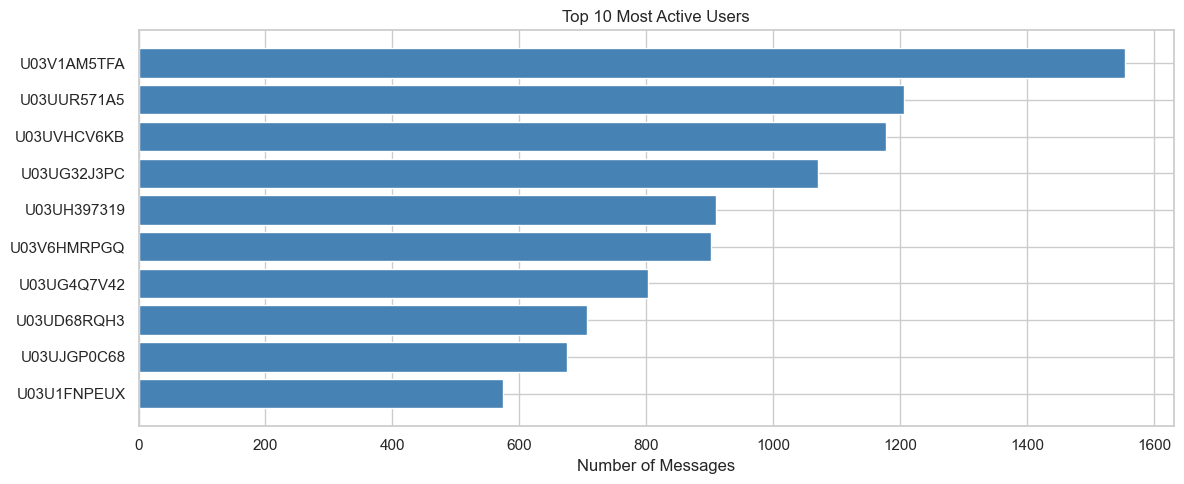

In [20]:
# Horizontal bar chart - top 10 most active users
top10 = user_stats.head(10)

fig, ax = plt.subplots()
ax.barh(top10.index, top10['message_count'], color='steelblue')
ax.set_xlabel('Number of Messages')
ax.set_title('Top 10 Most Active Users')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

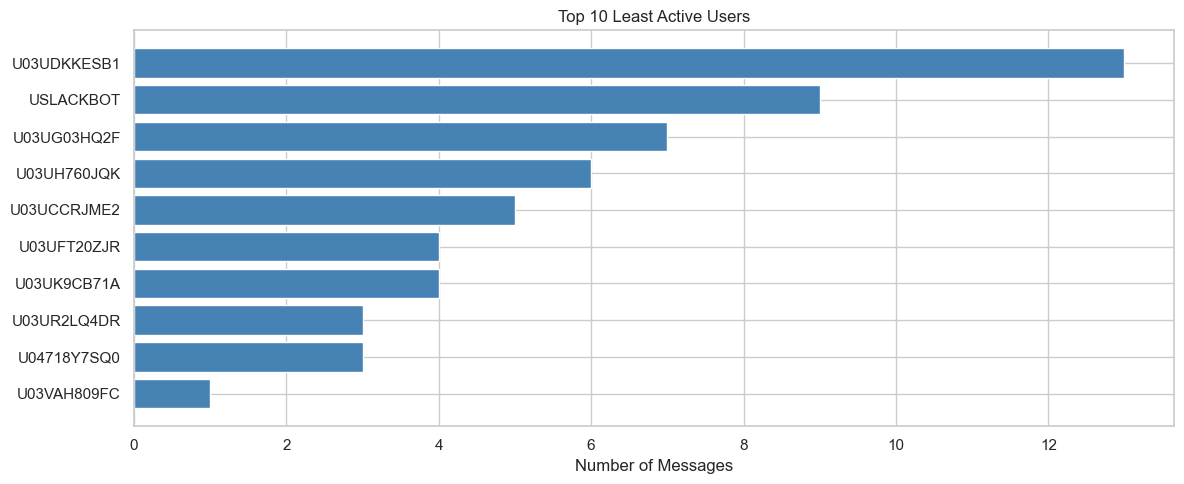

In [21]:
# Horizontal bar chart - top 10 least active users
top10 = user_stats.tail(10)

fig, ax = plt.subplots()
ax.barh(top10.index, top10['message_count'], color='steelblue')
ax.set_xlabel('Number of Messages')
ax.set_title('Top 10 Least Active Users')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Channel with highest total activity:


,messages,replies,reactions,replies_plus_reactions,total_activity
channel,,,,,
all-community-building,8302,3894,7043,10937,19239
all-career-exercises,828,475,589,1064,1892
all-resources,1506,89,249,338,1844
random,715,429,555,984,1699
kafka_de,958,390,54,444,1402
all-week1,596,426,113,539,1135
all-broadcast,559,186,327,513,1072
all-week7,555,361,148,509,1064
all-week5,536,395,88,483,1019


Channel appearing closest to the top-right corner:


,messages,replies,reactions,replies_plus_reactions,total_activity
channel,,,,,
all-community-building,8302,3894,7043,10937,19239


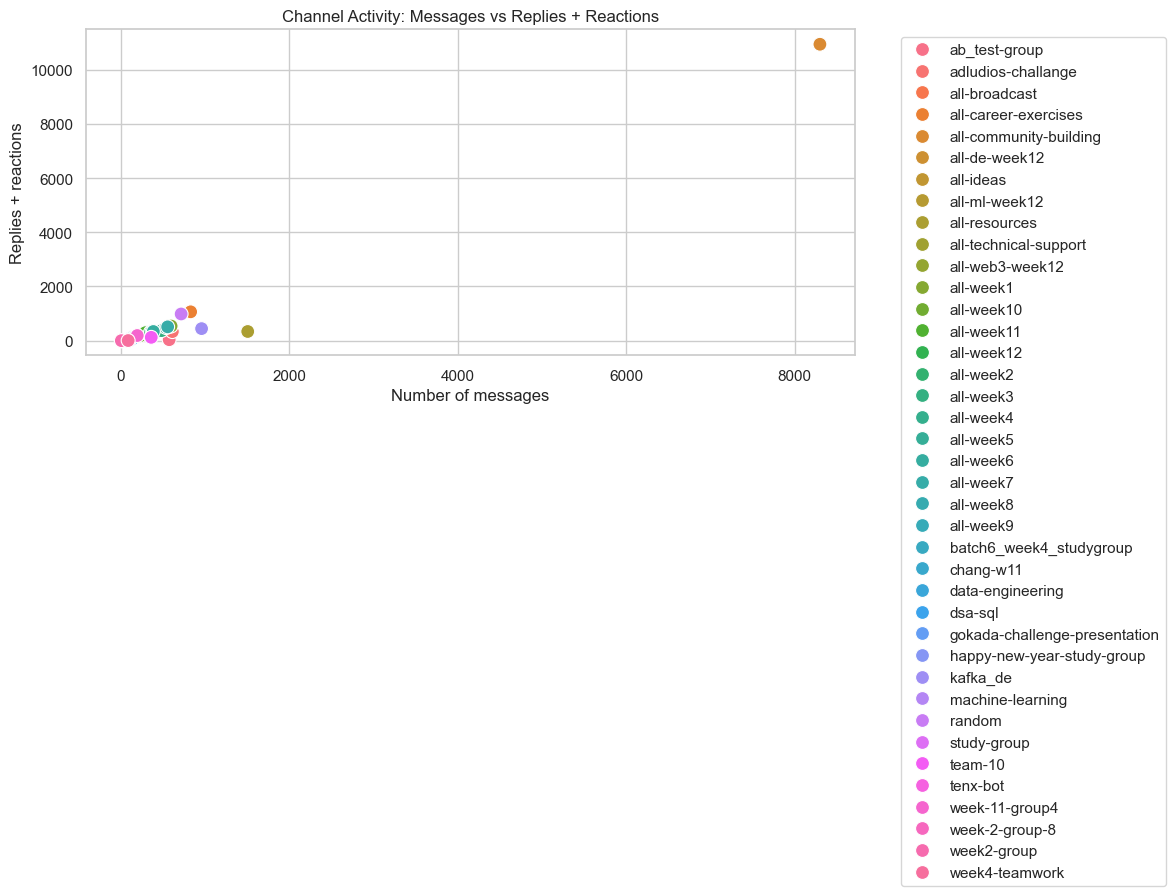

In [22]:
channel_stats = df_all.groupby("channel").agg(
    messages=("channel", "size"),
    replies=("reply_count", "sum"),
    reactions=("reaction_count", "sum")
)

channel_stats["replies_plus_reactions"] = channel_stats["replies"] + channel_stats["reactions"]
channel_stats["total_activity"] = channel_stats["messages"] + channel_stats["replies_plus_reactions"]

print("Channel with highest total activity:")
display(channel_stats.sort_values("total_activity", ascending=False).head(10))

top_right_channel = channel_stats.sort_values(
    ["messages", "replies_plus_reactions"],
    ascending=False
).head(1)

print("Channel appearing closest to the top-right corner:")
display(top_right_channel)

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=channel_stats.reset_index(),
    x="messages",
    y="replies_plus_reactions",
    hue="channel",
    s=100
)

plt.title("Channel Activity: Messages vs Replies + Reactions")
plt.xlabel("Number of messages")
plt.ylabel("Replies + reactions")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [23]:
replied_messages = df_all[df_all["reply_time_minutes"].notna()].copy()

within_5 = replied_messages[replied_messages["reply_time_minutes"] <= 5]

fraction_within_5 = len(within_5) / len(replied_messages) if len(replied_messages) > 0 else 0

print(f"Messages with replies: {len(replied_messages)}")
print(f"Messages replied within 5 minutes: {len(within_5)}")
print(f"Fraction replied within 5 minutes: {fraction_within_5:.2%}")

Messages with replies: 2027
Messages replied within 5 minutes: 1356
Fraction replied within 5 minutes: 66.90%


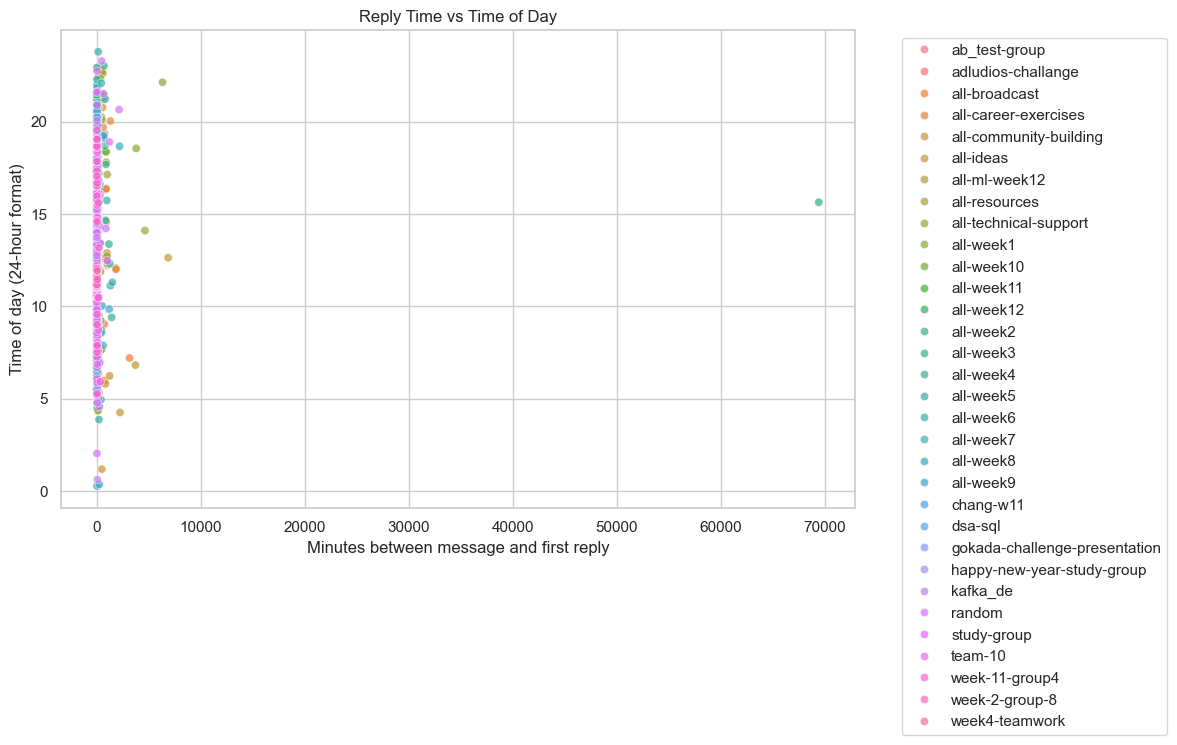

In [24]:
plot_df = df_all[
    df_all["reply_time_minutes"].notna()
    & (df_all["reply_time_minutes"] >= 0)
].copy()

plot_df["time_of_day"] = plot_df["datetime"].dt.hour + plot_df["datetime"].dt.minute / 60

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_df,
    x="reply_time_minutes",
    y="time_of_day",
    hue="channel",
    alpha=0.7
)

plt.title("Reply Time vs Time of Day")
plt.xlabel("Minutes between message and first reply")
plt.ylabel("Time of day (24-hour format)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [25]:
df_all.columns.tolist()

['type',
 'subtype',
 'ts',
 'user',
 'text',
 'blocks',
 'attachments',
 'channel',
 'date',
 'inviter',
 'client_msg_id',
 'team',
 'user_team',
 'source_team',
 'user_profile.avatar_hash',
 'user_profile.image_72',
 'user_profile.first_name',
 'user_profile.real_name',
 'user_profile.display_name',
 'user_profile.team',
 'user_profile.name',
 'user_profile.is_restricted',
 'user_profile.is_ultra_restricted',
 'reactions',
 'files',
 'upload',
 'display_as_bot',
 'edited.user',
 'edited.ts',
 'thread_ts',
 'reply_count',
 'reply_users_count',
 'latest_reply',
 'reply_users',
 'replies',
 'is_locked',
 'subscribed',
 'parent_user_id',
 'root.type',
 'root.text',
 'root.files',
 'root.upload',
 'root.user',
 'root.display_as_bot',
 'root.ts',
 'root.blocks',
 'root.client_msg_id',
 'root.thread_ts',
 'root.reply_count',
 'root.reply_users_count',
 'root.latest_reply',
 'root.reply_users',
 'root.replies',
 'root.is_locked',
 'root.subscribed',
 'no_notifications',
 'permalink',
 'room.

In [26]:
# Sort all messages chronologically
msgs = df_all.sort_values("datetime").copy()

# Difference between consecutive messages
msgs["msg_gap_minutes"] = (
    msgs["datetime"].diff().dt.total_seconds() / 60
)

msgs["msg_gap_minutes"].describe()

count    20010.000000
mean        11.588817
std        424.255346
min          0.000000
25%          0.140445
50%          0.494213
75%          1.992363
max      56399.879759
Name: msg_gap_minutes, dtype: float64

In [27]:
replys = df_all[
    df_all["first_reply_datetime"].notna()
].copy()

replys = replys.sort_values("first_reply_datetime")

replys["reply_gap_minutes"] = (
    replys["first_reply_datetime"].diff().dt.total_seconds() / 60
)

In [28]:
messages = df_all.sort_values("datetime").copy()

messages["message_gap_minutes"] = (
    messages["datetime"].diff().dt.total_seconds() / 60
)

messages["message_gap_minutes"].describe()

count    20010.000000
mean        11.588817
std        424.255346
min          0.000000
25%          0.140445
50%          0.494213
75%          1.992363
max      56399.879759
Name: message_gap_minutes, dtype: float64

In [29]:
replies = df_all[
    df_all["first_reply_datetime"].notna()
].copy()

replies = replies.sort_values("first_reply_datetime")

replies["reply_gap_minutes"] = (
    replies["first_reply_datetime"].diff().dt.total_seconds() / 60
)

replies["reply_gap_minutes"].describe()

count    2026.000000
mean       68.110945
std       242.965983
min         0.000000
25%         1.148894
50%         4.992100
75%        38.807554
max      4647.542121
Name: reply_gap_minutes, dtype: float64

In [30]:
event_times = []

event_times.extend(
    df_all["datetime"].dropna().tolist()
)

event_times.extend(
    df_all["first_reply_datetime"].dropna().tolist()
)

events = pd.DataFrame({
    "event_time": sorted(event_times)
})

events["event_gap_minutes"] = (
    events["event_time"].diff().dt.total_seconds() / 60
)

events["event_gap_minutes"].describe()

count    22037.000000
mean        10.522858
std        404.285846
min          0.000000
25%          0.076810
50%          0.391441
75%          1.639242
max      56399.879759
Name: event_gap_minutes, dtype: float64

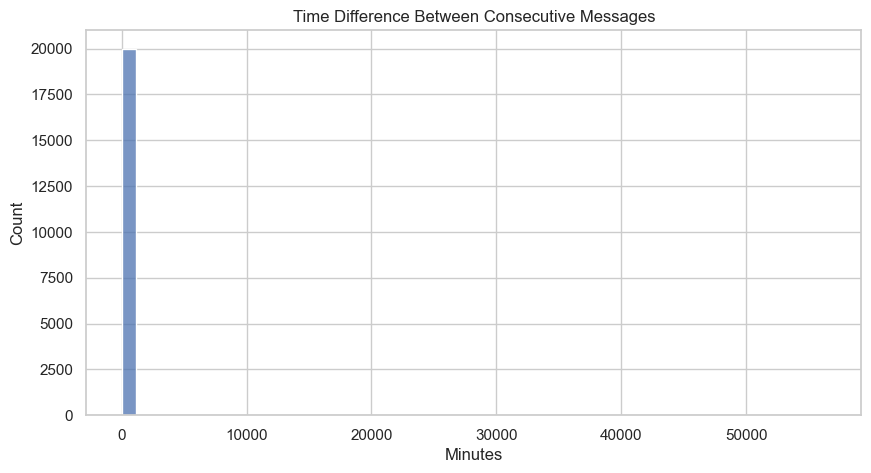

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(
    messages["message_gap_minutes"].dropna(),
    bins=50
)

plt.title("Time Difference Between Consecutive Messages")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

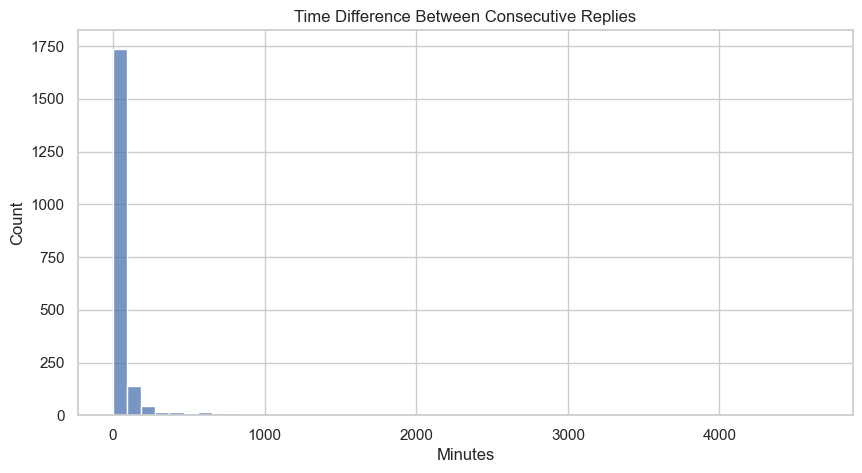

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    replies["reply_gap_minutes"].dropna(),
    bins=50
)

plt.title("Time Difference Between Consecutive Replies")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

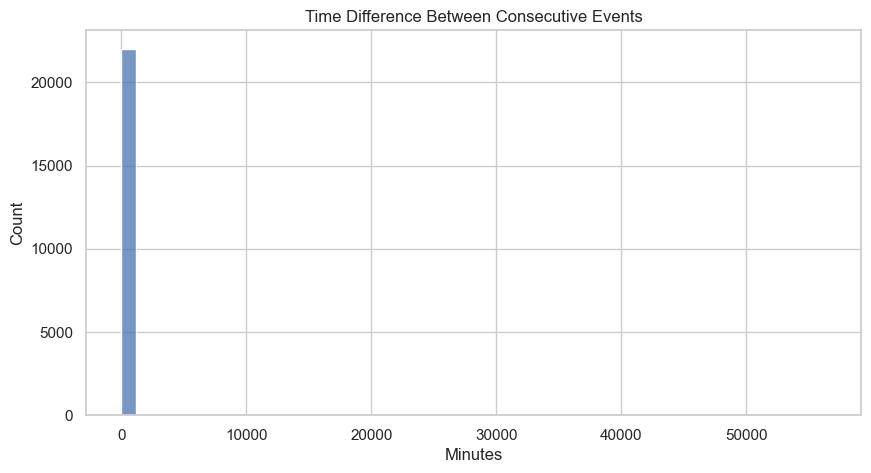

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    events["event_gap_minutes"].dropna(),
    bins=50
)

plt.title("Time Difference Between Consecutive Events")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

In [34]:
# MLOps Components

## A feature store is a centralized repository for storing and managing features used by machine learning models. It helps ensure consistency between training and inference data.

## Model Versioning allows tracking different versions of machine learning models, making experiments reproducible and simplifying rollback to previous versions.

## Model Monitoringt racks model performance after deployment and helps detect data drift, concept drift, and performance degradation.

## CI/CD for ML automates testing, validation, and deployment of machine learning code and models, ensuring reliable and repeatable workflows.

## Docker packages applications and dependencies into portable containers, making deployments reproducible across environments.

## Unit tests validate individual components of a machine learning pipeline to ensure expected behavior and reduce bugs.

## MLFlow is an MLOps platform used to track experiments, store model artifacts, version models, and manage the machine learning lifecycle.

SyntaxError: invalid syntax (2581164073.py, line 4)

In [35]:
import sklearn
print(sklearn.__version__)

1.9.0


In [ ]:
# Task 2: Topic Modelling

In [36]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Prepare text data
topic_df = df_all[df_all["text"].notna()].copy()
topic_df = topic_df[topic_df["text"].str.strip() != ""]

texts = topic_df["text"].astype(str)

vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=5,
    stop_words="english",
    max_features=1000
)

text_matrix = vectorizer.fit_transform(texts)

lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42
)

lda.fit(text_matrix)

feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: like, don, new, day, task, grin, make, think, better, way
Topic 2: joy, stephanie, meet, session, com, time, ysb, kjdn, hpp, http
Topic 3: hello, thanks, try, man, okay, group, let, u03uur571a5, people, did
Topic 4: just, know, week, need, hi, does, great, really, help, got
Topic 5: yes, good, thank, right, u03v1am5tfa, morning, share, ok, u03uvhcv6kb, problem
Topic 6: work, challenge, guys, sure, think, working, grinning, time, independent, today
Topic 7: data, rolling_on_the_floor_laughing, use, yeah, using, youtu, airflow, slack, code, test
Topic 8: today, link, joanne, week, high, meeting, questions, low, join, standup
Topic 9: https, com, www, youtube, watch, amp, org, docs, blog, python
Topic 10: channel, joined, file, error, dvc, home, install, u03ukl27b0r, py, git


In [37]:
df_all["channel"].value_counts().head(10)

channel
all-community-building    8302
all-resources             1506
kafka_de                   958
all-career-exercises       828
random                     715
adludios-challange         611
all-week1                  596
ab_test-group              573
all-broadcast              559
all-week7                  555
Name: count, dtype: int64

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

top_channels = (
    df_all["channel"]
    .value_counts()
    .head(10)
    .index
)

for channel in top_channels:

    print("\n" + "="*60)
    print("CHANNEL:", channel)

    channel_df = df_all[
        (df_all["channel"] == channel)
        & (df_all["text"].notna())
    ]

    texts = channel_df["text"].astype(str)

    if len(texts) < 20:
        print("Not enough messages")
        continue

    vectorizer = CountVectorizer(
        stop_words="english",
        max_df=0.90,
        min_df=3,
        max_features=500
    )

    X = vectorizer.fit_transform(texts)

    lda = LatentDirichletAllocation(
        n_components=1,
        random_state=42
    )

    lda.fit(X)

    feature_names = vectorizer.get_feature_names_out()

    topic = lda.components_[0]

    top_words = [
        feature_names[i]
        for i in topic.argsort()[-10:][::-1]
    ]

    print("Top topic words:")
    print(", ".join(top_words))


CHANNEL: all-community-building
Top topic words:
joy, rolling_on_the_floor_laughing, hello, good, time, like, high, today, cbs, know

CHANNEL: all-resources
Top topic words:
https, com, www, youtube, watch, org, blog, docs, python, data

CHANNEL: kafka_de
Top topic words:
yes, working, data, just, try, category, file, meeting, think, using

CHANNEL: all-career-exercises
Top topic words:
com, channel, https, questions, stephanie, think, good, exercise, job, joanne

CHANNEL: random
Top topic words:
https, com, joy, www, amp, youtube, rolling_on_the_floor_laughing, watch, share, linkedin

CHANNEL: adludios-challange
Top topic words:
think, data, good, u03ug32j3pc, image, working, logo, guys, need, yes

CHANNEL: all-week1
Top topic words:
data, https, use, com, think, thank, task, thanks, help, channel

CHANNEL: ab_test-group
Top topic words:
work, repo, u03ug4q7v42, u03ud4fedhb, u03u9fwpnce, okay, u03u1hag9tr, data, task, branch

CHANNEL: all-broadcast
Top topic words:
stephanie, meet, c

In [39]:
from textblob import TextBlob

sentiment_df = df_all.copy()

sentiment_df["date_only"] = sentiment_df["datetime"].dt.date

daily_text = (
    sentiment_df
    .groupby("date_only")["text"]
    .apply(lambda x: " ".join(x.dropna().astype(str)))
    .reset_index()
)

daily_text.head()

,date_only,text
0,2022-08-12,<@u03tepyrm2p> has joined the channel changed ...
1,2022-08-18,<@u03u9db7reg> has joined the channel <@u03ukl...
2,2022-08-19,<@u03up7v9q57> has joined the channel <@u03udb...
3,2022-08-20,<@u03u1fnpeux> has joined the channel <@u03u1f...
4,2022-08-21,"hi all, looking forward to starting together, ..."


In [40]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

daily_text["sentiment"] = daily_text["text"].apply(get_sentiment)

daily_text.head()

,date_only,text,sentiment
0,2022-08-12,<@u03tepyrm2p> has joined the channel changed ...,0.000000
1,2022-08-18,<@u03u9db7reg> has joined the channel <@u03ukl...,0.000000
2,2022-08-19,<@u03up7v9q57> has joined the channel <@u03udb...,0.000000
3,2022-08-20,<@u03u1fnpeux> has joined the channel <@u03u1f...,0.811830
4,2022-08-21,"hi all, looking forward to starting together, ...",0.491667


In [41]:
daily_text["days_since_start"] = (
    pd.to_datetime(daily_text["date_only"])
    - pd.to_datetime(daily_text["date_only"]).min()
).dt.days

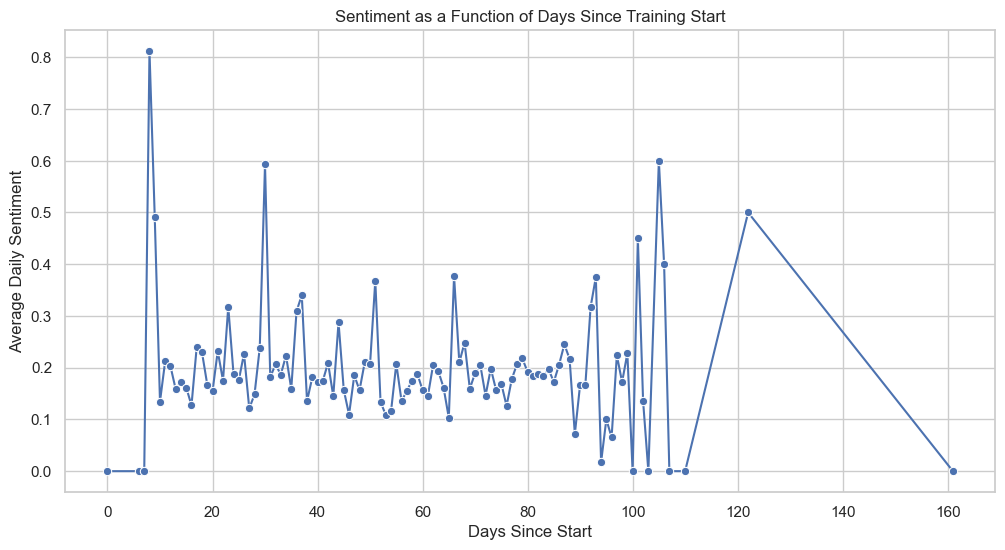

In [42]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=daily_text,
    x="days_since_start",
    y="sentiment",
    marker="o"
)

plt.title("Sentiment as a Function of Days Since Training Start")
plt.xlabel("Days Since Start")
plt.ylabel("Average Daily Sentiment")
plt.grid(True)

plt.show()

In [43]:
print(daily_text["sentiment"].describe())

count    105.000000
mean       0.197489
std        0.125917
min        0.000000
25%        0.146167
50%        0.181316
75%        0.217217
max        0.811830
Name: sentiment, dtype: float64


In [44]:
print("Most Positive Day:")
display(
    daily_text.sort_values("sentiment", ascending=False)
    .head(3)
)

print("Most Negative Day:")
display(
    daily_text.sort_values("sentiment")
    .head(3)
)

Most Positive Day:


,date_only,text,sentiment,days_since_start
3,2022-08-20,<@u03u1fnpeux> has joined the channel <@u03u1f...,0.811830,8
99,2022-11-25,you all need this kind of friend :rolling_on_t...,0.600000,105
25,2022-09-11,*best submissions for week 2 challenge : a/b h...,0.592857,30


Most Negative Day:


,date_only,text,sentiment,days_since_start
0,2022-08-12,<@u03tepyrm2p> has joined the channel changed ...,0.0,0
1,2022-08-18,<@u03u9db7reg> has joined the channel <@u03ukl...,0.0,6
2,2022-08-19,<@u03up7v9q57> has joined the channel <@u03udb...,0.0,7


In [45]:
# Sentiment Analysis Observations

# Sentiment analysis was performed by aggregating all messages for each day and computing the sentiment polarity using TextBlob.

# The average sentiment score across the training period was approximately 0.20, indicating that discussions were generally positive. Most daily sentiment values were concentrated between 0.10 and 0.25, suggesting a relatively stable emotional tone throughout the training.

# Several days exhibited notable positive spikes, with the maximum sentiment reaching approximately 0.81. These spikes may correspond to highly engaging discussions, successful task completions, collaborative activities, or community events.

# No strong downward trend was observed, indicating that the overall atmosphere of the workspace remained positive and supportive over time.

In [46]:
# Message classification

In [47]:
technical_keywords = [
    "python", "pandas", "data", "model", "error", "bug", "git", "github",
    "repo", "branch", "docker", "mlflow", "api", "database", "sql",
    "kafka", "airflow", "code", "install", "file", "kernel", "notebook"
]

answer_keywords = [
    "yes", "no", "try", "use", "you can", "should", "fixed", "solved",
    "because", "the issue", "it works", "here is", "this means"
]

def classify_message(text):
    text = str(text).lower().strip()

    if text == "" or text == "nan":
        return "other"

    is_question = "?" in text or text.startswith(("how", "what", "why", "when", "where", "can", "does", "is", "are"))
    is_technical = any(keyword in text for keyword in technical_keywords)
    is_answer = any(keyword in text for keyword in answer_keywords)

    if is_question and is_technical:
        return "technical_question"
    elif is_question:
        return "nontechnical_question"
    elif is_answer and is_technical:
        return "technical_answer"
    elif is_answer:
        return "answer"
    elif is_technical:
        return "technical_comment"
    else:
        return "nontechnical_comment"


df_all["message_class"] = df_all["text"].apply(classify_message)

df_all["message_class"].value_counts()

message_class
nontechnical_comment     10714
answer                    3450
nontechnical_question     2724
technical_comment         1159
technical_answer           861
technical_question         694
other                      409
Name: count, dtype: int64

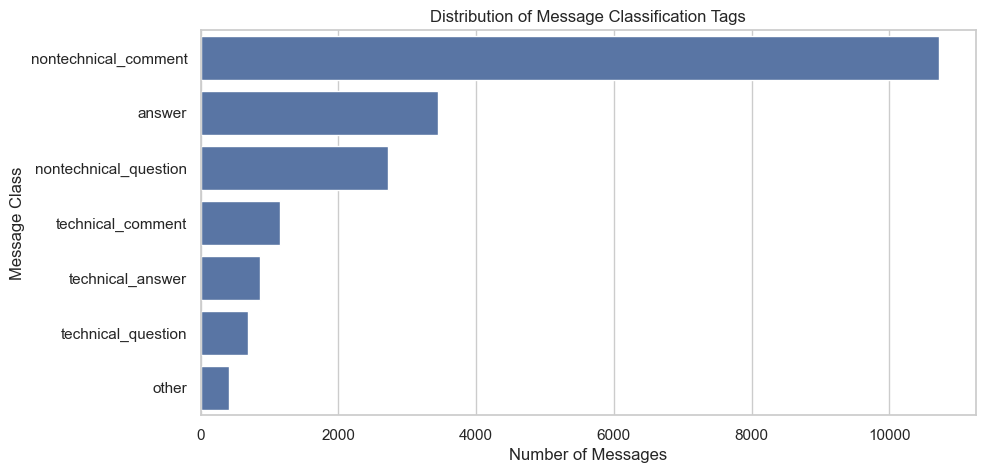

In [48]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_all,
    y="message_class",
    order=df_all["message_class"].value_counts().index
)

plt.title("Distribution of Message Classification Tags")
plt.xlabel("Number of Messages")
plt.ylabel("Message Class")
plt.show()

In [49]:
import mlflow
import mlflow.pyfunc
import pandas as pd


class RuleBasedMessageClassifier(mlflow.pyfunc.PythonModel):
    def predict(self, context, model_input):
        return model_input["text"].apply(classify_message)


mlflow.set_experiment("slack_message_classification")

with mlflow.start_run(run_name="rule_based_message_classifier"):

    mlflow.log_param("model_type", "rule_based_classifier")
    mlflow.log_param("num_messages", len(df_all))
    mlflow.log_param("num_classes", df_all["message_class"].nunique())

    class_counts = df_all["message_class"].value_counts().to_dict()

    for label, count in class_counts.items():
        mlflow.log_metric(f"class_count_{label}", count)

    sample_input = df_all[["text"]].head(20)

    mlflow.pyfunc.log_model(
        artifact_path="rule_based_message_classifier",
        python_model=RuleBasedMessageClassifier(),
        input_example=sample_input
    )

print("MLFlow run completed.")

C:\Users\eyobg\Desktop\Internship Training\notebook\week1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\eyobg\Desktop\Internship Training\notebook\week1\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/06/16 00:52:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 00:52:28 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code 

MLFlow run completed.


In [50]:
df_all
daily_text

,date_only,text,sentiment,days_since_start
0,2022-08-12,<@u03tepyrm2p> has joined the channel changed ...,0.000000,0
1,2022-08-18,<@u03u9db7reg> has joined the channel <@u03ukl...,0.000000,6
2,2022-08-19,<@u03up7v9q57> has joined the channel <@u03udb...,0.000000,7
3,2022-08-20,<@u03u1fnpeux> has joined the channel <@u03u1f...,0.811830,8
4,2022-08-21,"hi all, looking forward to starting together, ...",0.491667,9
...,...,...,...,...
100,2022-11-26,*job search workspace*\n<!channel> kindly join...,0.400000,106
101,2022-11-27,<https://resources.biginterview.com/interview-...,0.000000,107
102,2022-11-30,"hey <!channel>, can everyone work on deploymen...",0.000000,110
103,2022-12-12,"<!channel> <!here> hello buddies, its my hope ...",0.500000,122


In [51]:
print(type(df_all))
print(df_all.shape)

print(type(daily_text))
print(daily_text.shape)

<class 'pandas.core.frame.DataFrame'>
(20011, 114)
<class 'pandas.core.frame.DataFrame'>
(105, 4)


In [52]:
df_all.columns.tolist()

['type',
 'subtype',
 'ts',
 'user',
 'text',
 'blocks',
 'attachments',
 'channel',
 'date',
 'inviter',
 'client_msg_id',
 'team',
 'user_team',
 'source_team',
 'user_profile.avatar_hash',
 'user_profile.image_72',
 'user_profile.first_name',
 'user_profile.real_name',
 'user_profile.display_name',
 'user_profile.team',
 'user_profile.name',
 'user_profile.is_restricted',
 'user_profile.is_ultra_restricted',
 'reactions',
 'files',
 'upload',
 'display_as_bot',
 'edited.user',
 'edited.ts',
 'thread_ts',
 'reply_count',
 'reply_users_count',
 'latest_reply',
 'reply_users',
 'replies',
 'is_locked',
 'subscribed',
 'parent_user_id',
 'root.type',
 'root.text',
 'root.files',
 'root.upload',
 'root.user',
 'root.display_as_bot',
 'root.ts',
 'root.blocks',
 'root.client_msg_id',
 'root.thread_ts',
 'root.reply_count',
 'root.reply_users_count',
 'root.latest_reply',
 'root.reply_users',
 'root.replies',
 'root.is_locked',
 'root.subscribed',
 'no_notifications',
 'permalink',
 'room.

In [55]:
from sqlalchemy import create_engine

DB_USER = "postgres"
DB_PASSWORD = "Skibidi789!"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "slack_features"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [56]:
users_features = df_all.groupby("user").agg(
    message_count=("user", "size"),
    reply_count=("reply_count", "sum"),
    mention_count=("mention_count", "sum"),
    reaction_count=("reaction_count", "sum")
).reset_index().rename(columns={"user": "user_id"})

users_features.to_sql(
    "users_features",
    engine,
    if_exists="replace",
    index=False
)

users_features.head()

,user_id,message_count,reply_count,mention_count,reaction_count
0,U03T89ACUUW,185,89,90,143
1,U03TEPYRM2P,222,28,51,240
2,U03TT5KEYCF,156,73,64,213
3,U03TX2VN6H5,18,0,18,0
4,U03U1FNPEUX,575,308,88,360


In [57]:
message_features = df_all.copy()

message_features["message_id"] = message_features["channel"].astype(str) + "_" + message_features["ts"].astype(str)

message_features = message_features[[
    "message_id",
    "channel",
    "user",
    "datetime",
    "text",
    "reply_count",
    "mention_count",
    "reaction_count",
    "message_class"
]].rename(columns={
    "channel": "channel_name",
    "user": "user_id",
    "datetime": "timestamp"
})

message_features["sentiment_score"] = message_features["text"].astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)

message_features.to_sql(
    "message_features",
    engine,
    if_exists="replace",
    index=False
)

message_features.head()

,message_id,channel_name,user_id,timestamp,text,reply_count,mention_count,reaction_count,message_class,sentiment_score
0,ab_test-group_1661765937.810099,ab_test-group,U03U9FWPNCE,2022-08-29 09:38:57.810098886,<@u03u9fwpnce> has joined the channel,0,1,0,nontechnical_comment,0.0
1,ab_test-group_1661765994.399499,ab_test-group,U03UD4FEDHB,2022-08-29 09:39:54.399498940,<@u03ud4fedhb> has joined the channel,0,1,0,nontechnical_comment,0.0
2,ab_test-group_1661765994.453809,ab_test-group,U03U1HAG9TR,2022-08-29 09:39:54.453809023,<@u03u1hag9tr> has joined the channel,0,1,0,nontechnical_comment,0.0
3,ab_test-group_1661765994.542189,ab_test-group,U03UG4Q7V42,2022-08-29 09:39:54.542188883,<@u03ug4q7v42> has joined the channel,0,1,0,nontechnical_comment,0.0
4,ab_test-group_1661766066.863109,ab_test-group,U03U9FWPNCE,2022-08-29 09:41:06.863109112,"hi guys,\ni thought having a group chat would ...",0,2,0,nontechnical_question,0.7


In [58]:
daily_sentiment_features = daily_text.copy()

daily_sentiment_features = daily_sentiment_features.rename(columns={
    "date_only": "date",
    "sentiment": "sentiment_score"
})

daily_sentiment_features = daily_sentiment_features[[
    "date",
    "days_since_start",
    "sentiment_score"
]]

daily_sentiment_features.to_sql(
    "daily_sentiment_features",
    engine,
    if_exists="replace",
    index=False
)

daily_sentiment_features.head()

,date,days_since_start,sentiment_score
0,2022-08-12,0,0.000000
1,2022-08-18,6,0.000000
2,2022-08-19,7,0.000000
3,2022-08-20,8,0.811830
4,2022-08-21,9,0.491667
